# Coursework 2 Part 1
**Replace CID in the file name with your CID**

# Outline


- [Task 1](#task-1): Classification with a Convolutional Neural Network <a name="index-task-1"></a>
  - [(1.1)](#task-11) <a name="index-task-11"></a>
  - [(1.2)](#task-12) <a name="index-task-12"></a>
- [Task 2](#task-2): Dimensionality Reduction with Non-Negative Matrix Tri-Factorisation <a name="index-task-2"></a>
  - [(2.1)](#task-21) <a name="index-task-21"></a>
  - [(2.2)](#task-22)  <a name="index-task-22"></a>

<a name="task-1"></a>

# Task 1: Classification with a Convolutional Neural Network [(index)](#index-task-1)

In [318]:
# import useful packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch.nn import Sequential, CrossEntropyLoss, Conv1d, MaxPool1d, Flatten, Linear, ReLU, Softmax, Parameter, Dropout
from torch.utils.data import TensorDataset, DataLoader

# set global config for matplotlib to make plots readable
SMALL_SIZE = 12
MEDIUM_SIZE = 16
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

rng = np.random.default_rng(0)

In [319]:
# load data
data = pd.read_csv("neural_activity.csv")

# show the shape of the data
print("train data shape: ", data.shape)

# Map labels
label_map = {'R': 0, 'L': 1, 'F': 2, 'B': 3}
data['Trial Type'] = data['Trial Type'].map(label_map)

data.head()

train data shape:  (3200, 203)


,Count at t=1,Count at t=2,Count at t=3,Count at t=4,Count at t=5,Count at t=6,Count at t=7,Count at t=8,Count at t=9,Count at t=10,...,Count at t=194,Count at t=195,Count at t=196,Count at t=197,Count at t=198,Count at t=199,Count at t=200,Brain Region Index,Trial Index,Trial Type
0,25,25,26,27,27,28,29,30,31,32,...,64,66,67,69,71,72,73,1,1,3
1,68,68,69,69,70,71,71,72,72,73,...,38,37,37,36,35,35,33,1,2,2
2,30,29,29,29,29,29,29,30,30,31,...,33,32,31,30,29,28,27,1,3,1
3,24,25,26,28,29,31,32,35,37,39,...,94,93,91,90,88,86,84,1,4,0
4,59,59,59,59,59,58,58,58,58,59,...,37,34,33,31,29,28,26,1,5,2


In [320]:
# The number of brain regions and trials
N_Brain_Region = data["Brain Region Index"].unique().shape[0]
N_Trial_Index = data["Trial Index"].unique().shape[0]

# Reshape the data to N_trial x N_region x p
data_reshaped = np.asarray(data).reshape(N_Brain_Region, N_Trial_Index, -1).transpose((1, 0, 2))

# Split train and test data
test_idx = [56, 30, 42, 63, 7, 66, 2, 77, 78, 13, 39, 61, 5, 67, 70, 46]
all_idx = np.arange(len(data_reshaped))
train_idx = np.setdiff1d(all_idx, test_idx)
test_data = data_reshaped[test_idx]
train_data = data_reshaped[train_idx]

# Split the features and labels
X_train = train_data[:, :, :200]
X_test = test_data[:, :, :200]
y_train = train_data[:, 0, -1]
y_test = test_data[:, 0, -1]

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(64, 40, 200)
(64,)
(16, 40, 200)
(16,)


In [321]:
# from week 8
def normalize_nmf(X, X_train_ = None):
    """
    Globally normalise features.

    Parameters:
        X (np.array): Feature matrix.

    Returns:b
        X_norm (np.array): Normalised feature matrix
    """

    X_norm = (X- np.min(X)) / (np.max(X) - np.min(X))  ## <-- SOLUTION
    return X_norm

X_train_norm = normalize_nmf(X_train)
X_test_norm = normalize_nmf(X_test)

<a name="task-11"></a>

## (1.1) [(index)](#index-task-11)

In [322]:
def get_model(x_train, n_filters=8, k=16, pool_size=16, stride_pool=4, classes=[0, 1, 2, 3]):
    """
    CNN model in PyTorch:
    - Layers are Conv1d(+ReLU), MaxPool1d, Flatten and Linear(+Softmax).
    - It features an Adam optimiser and CrossEntropyLoss criterion.

    Parameters:
        x_train (np.ndarray): Training data
        n_filters (int): Number of filters to be used in the convolutional layer
        k (int): Kernel size in the convolutional layer
        pool_size (int): MaxPool1d window size
        stride_pool (int): Stride of the MaxPool1d sliding window
        classes (List): Output classes

    Returns:
        Model, criterion and optimiser.

    """

    l_out_conv = x_train.shape[2] - k + 1 # Length after Conv1d (note that the stride is 1)
    l_out_pool = (l_out_conv - pool_size) // stride_pool + 1 # Length after MaxPool1d
    l_in_linear = n_filters * l_out_pool # Size before Linear layer

    model = Sequential(
        Conv1d(x_train.shape[1], n_filters, kernel_size=k, dtype=x_train.dtype),
        ReLU(),
        MaxPool1d(kernel_size=pool_size, stride=stride_pool),
        Flatten(),
        Dropout(p=0.8),
        Linear(l_in_linear, len(classes), dtype=x_train.dtype),
    )

    criterion = CrossEntropyLoss()
    optimiser = torch.optim.Adam(model.parameters())

    return model, criterion, optimiser

In [323]:
# Numpy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train_norm, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_norm, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train)
y_test_tensor = torch.tensor(y_test)

# Creating training and validation datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor.squeeze())
test_dataset = TensorDataset(X_test_tensor, y_test_tensor.squeeze())

# Creating corresponding DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16)
tset_loader = DataLoader(test_dataset, batch_size=16)

In [324]:
# Set seed
torch.manual_seed(10)

# Create model, loss function and optimiser
model_CNN, criterion, optimiser = get_model(X_train_tensor)
print(model_CNN)

Sequential(
  (0): Conv1d(40, 8, kernel_size=(16,), stride=(1,))
  (1): ReLU()
  (2): MaxPool1d(kernel_size=16, stride=4, padding=0, dilation=1, ceil_mode=False)
  (3): Flatten(start_dim=1, end_dim=-1)
  (4): Dropout(p=0.8, inplace=False)
  (5): Linear(in_features=344, out_features=4, bias=True)
)


In [ ]:
def training_loop(train_loader, num_epochs=100):
    """
    Training loop.

    Parameters:
        train_loader (torch.utils.data.DataLoader): Training DataLoader
        num_epochs (int): number of epochs

    Returns:
        Model, criterion and optimiser and train_loss list.

    """
    train_loss = []

    for epoch in range(num_epochs):

        # Training
        model_CNN.train()
        for inputs, labels in train_loader:
            optimiser.zero_grad() # Setting gradients to zero
            outputs = model_CNN(inputs)
            loss = criterion(outputs, labels)
            loss.backward() # Computes gradients of the loss
            optimiser.step() # Optimisation step (parameters are updated)

        model_CNN.eval()
        with torch.no_grad():
            train_out = model_CNN(X_train_tensor)
            epoch_loss = criterion(train_out, y_train_tensor).item()
            train_loss.append(epoch_loss)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'Epoch {epoch + 1}/{num_epochs}, Training loss: {epoch_loss}')

    return model_CNN, criterion, optimiser, train_loss

In [ ]:
# Train
model_CNN, criterion, optimiser, train_loss = training_loop(train_loader=train_loader)

Epoch 1/100, Training loss: 1.3353
Epoch 10/100, Training loss: 0.9214
Epoch 20/100, Training loss: 0.4083
Epoch 30/100, Training loss: 0.1914
Epoch 40/100, Training loss: 0.0966
Epoch 50/100, Training loss: 0.0713
Epoch 60/100, Training loss: 0.0400
Epoch 70/100, Training loss: 0.0359
Epoch 80/100, Training loss: 0.0249
Epoch 90/100, Training loss: 0.0208
Epoch 100/100, Training loss: 0.0179


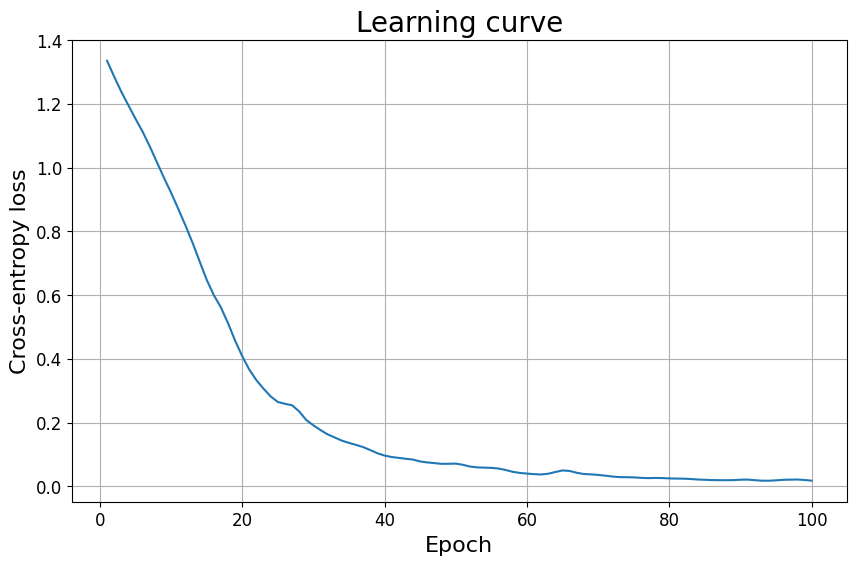

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, 100 + 1), train_loss)
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.title('Learning curve')
plt.grid(True)
plt.show()

In [338]:
model_CNN.eval()
with torch.no_grad():
    # Training accuracy
    train_preds = torch.argmax(model_CNN(X_train_tensor), dim=1)
    train_acc = (train_preds == y_train_tensor).float().mean()
    
    # Test accuracy
    test_preds = torch.argmax(model_CNN(X_test_tensor), dim=1)
    test_acc = (test_preds == y_test_tensor).float().mean()

print(f'Training accuracy: {train_acc * 100}%')
print(f'Test accuracy: {test_acc * 100}%')

Training accuracy: 100.0%
Test accuracy: 100.0%


<a name="task-12"></a>

## (1.2) [(index)](#index-task-12)

In [343]:
# Set model to training mode
model_CNN.train()

Q = 4
N_test = len(test_idx)
all_probs = torch.zeros(10, N_test, Q)

with torch.no_grad():
    for i in range(10):
        logits = model_CNN(X_test_tensor)
        probs = torch.softmax(logits, dim=1)
        all_probs[i] = probs

print(f'Prediction tensor shape: {all_probs.shape}')

Prediction tensor shape: torch.Size([10, 16, 4])


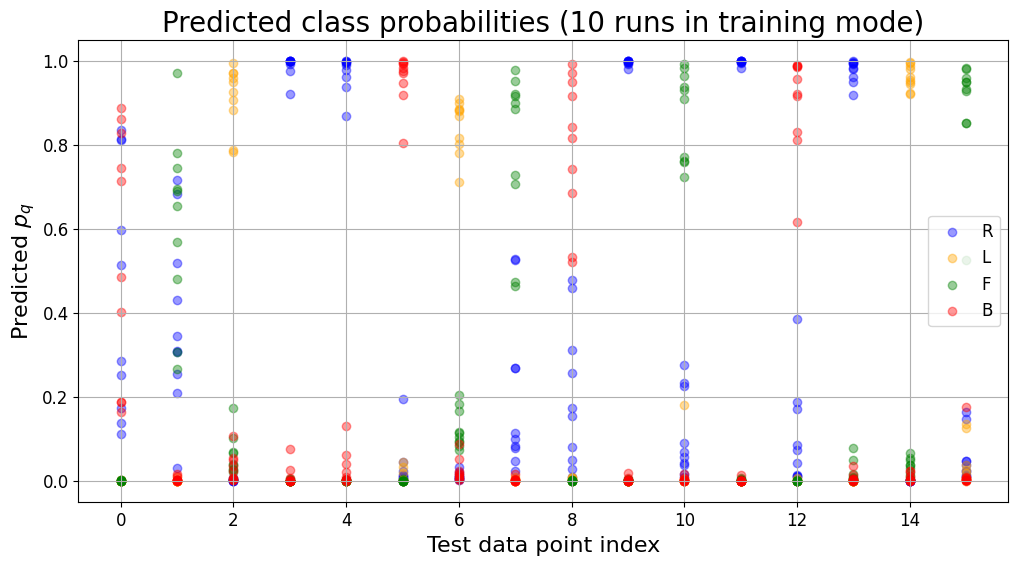

In [352]:
# Plot predicted probabilities
class_labels = ['R', 'L', 'F', 'B']
colors = ['blue', 'orange', 'green', 'red']

plt.figure(figsize=(12, 6))
for q in range(Q):
    for run in range(10):
        x_vals = np.arange(N_test)
        y_vals = all_probs[run, :, q]
        plt.scatter(x_vals, y_vals, c=colors[q], alpha=0.4,
                    label=class_labels[q] if run == 0 else None)

plt.xlabel('Test data point index')
plt.ylabel('Predicted $p_q$')
plt.title('Predicted class probabilities (10 runs in training mode)')
plt.grid(True)
plt.legend()
plt.show()

<a name="task-2"></a>

# Task 2: Dimensionality Reduction with Non-Negative Matrix Tri-Factorisation [(index)](#index-task-2)

<a name="task-21"></a>

## (2.1) [(index)](#index-task-21)

<a name="task-22"></a>

## (2.2) [(index)](#index-task-22)